# Module Trust / Fraud Detection Agent: Hệ thống Đánh giá Độ Tin cậy Người dùng (v2)

**Triết lý Thiết kế — Hiệu chuẩn Dữ liệu Tự động (Data-Driven Calibration):**
- **Không dùng trọng số gán cứng (Zero Hardcoded Weights):** Toàn bộ trọng số — từ nội tại từng trụ cột thành phần đến công thức tổng hợp cuối cùng — đều được tối ưu hóa và hiệu chuẩn trực tiếp trên tập **Validation Set (10%)** thông qua phương pháp quét lưới cực đại hóa khoảng cách phân biệt Kolmogorov-Smirnov (KS-statistic).
- **Đánh giá trên Test Set Độc lập (20%):** Mọi chỉ số an toàn (Bot Quarantine Recall, Tier 1 Human Precision, KS-statistic) được đo đạc khách quan trên tập dữ liệu người dùng chưa từng được mô hình nhìn thấy, triệt tiêu hoàn toàn rò rỉ dữ liệu (Data Leakage).
- **Cổng chặn Danh tính (Identity Gating - $G_{auth}$):** Triệt tiêu hiện tượng bù trừ điểm, cách ly tuyệt đối botnet và tài khoản giả mạo.
- **Hệ thống An toàn Đa tầng (Defense-in-Depth):** Bảo vệ người dùng trước cả bot tự động lẫn các hành vi lừa đảo/quấy rối/rải link từ người thật.

---

**Mục tiêu Nghiệp vụ:** Xác định xem các ứng viên trên đồ thị có đủ ĐỘ TIN CẬY VÀ AN TOÀN để đưa vào luồng Gợi ý Bạn bè (PYMK System) hay không!

**Mô hình Toán học Tổng quát (Parameterized Trust Formulation):**

$$S_{trust}(u) = 100 \times G_{auth}(u) \times \sum_{i=1}^4 w_i^* \cdot S_i(u)$$

Trong đó, vector trọng số tối ưu $\mathbf{w}^* = [w_{\text{auth}}^*, w_{\text{interact}}^*, w_{\text{network}}^*, w_{\text{content}}^*]$ thỏa mãn điều kiện lồi $\sum w_i = 1, w_i \ge 0$, và được tìm kiếm tự động từ dữ liệu tại Mục 9.


## 1. Thiết lập Môi trường & Import Thư viện

Khởi tạo các thư viện toán học, học sâu trên đồ thị (PyTorch), học máy (Scikit-Learn) và trực quan hóa (Matplotlib, Seaborn).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from itertools import product as iproduct
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
sns.set_theme(style="whitegrid", palette="muted")

# Thiết lập thư mục tương thích (chạy tại root hoặc trong CORE_NOTEBOOKS)
ROOT_DIR = os.path.dirname(os.getcwd()) if (not os.path.exists(os.path.join(os.getcwd(), 'MGTAB')) and os.path.exists(os.path.join(os.path.dirname(os.getcwd()), 'MGTAB'))) else os.getcwd()
DATA_DIR   = os.path.join(ROOT_DIR, 'MGTAB')
OUTPUT_DIR = os.path.join(ROOT_DIR, 'data')
PHOTOS_DIR = os.path.join(ROOT_DIR, 'photos')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PHOTOS_DIR, exist_ok=True)

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch Version: {torch.__version__}")
print(f"Thu muc du lieu: {DATA_DIR}")

PyTorch Version: 2.5.1+cpu
Thu muc du lieu: C:\Users\Admin\VSF_Notebook\MGTAB


## 2. Nạp Dữ liệu Đồ thị Đa Quan hệ (MGTAB)

Tập dữ liệu MGTAB gồm 10,199 người dùng, 1,700,108 liên kết thuộc 7 loại quan hệ (Following, Friend, Mention, Reply, Quoted, URL co-occurrence, Hashtag co-occurrence) và ma trận đặc trưng 788 chiều.

In [2]:
edge_index    = torch.load(os.path.join(DATA_DIR, 'edge_index.pt'),  map_location='cpu', weights_only=False)
edge_type     = torch.load(os.path.join(DATA_DIR, 'edge_type.pt'),   map_location='cpu', weights_only=False)
edge_weight   = torch.load(os.path.join(DATA_DIR, 'edge_weight.pt'), map_location='cpu', weights_only=False)
features      = torch.load(os.path.join(DATA_DIR, 'features.pt'),    map_location='cpu', weights_only=False)
labels_bot    = torch.load(os.path.join(DATA_DIR, 'labels_bot.pt'),  map_location='cpu', weights_only=False)
labels_stance = torch.load(os.path.join(DATA_DIR, 'labels_stance.pt'), map_location='cpu', weights_only=False)

labels_np        = labels_bot.numpy()
labels_stance_np = labels_stance.numpy()
num_nodes        = features.shape[0]
num_edges        = edge_index.shape[1]

src_all     = edge_index[0].numpy()
dst_all     = edge_index[1].numpy()
types_all   = edge_type.numpy()
weights_all = edge_weight.numpy()

print(f"So nut: {num_nodes:,}")
print(f"So canh: {num_edges:,}")
print(f"Chieu dac trung: {features.shape[1]}")
print(f"Bot = {(labels_np==1).sum():,}, Human = {(labels_np==0).sum():,}")

So nut: 10,199
So canh: 1,700,108
Chieu dac trung: 788
Bot = 2,748, Human = 7,451


## 3. Phân Chia Tập Dữ Liệu Stratified (Train 70% / Val 10% / Test 20%)

Để đảm bảo tính khoa học và không bị rò rỉ thông tin (Data Leakage):
- **Train Set (70%):** Dùng để huấn luyện mạng nơ-ron đồ thị R-GCN.
- **Validation Set (10%):** **DÙNG ĐỂ TỐI ƯU HÓA & HIỆU CHUẨN TẤT CẢ CÁC TRỌNG SỐ (Weight Calibration)**. Toàn bộ trọng số được thuật toán tự động tìm ra trên tập này.
- **Test Set (20%):** Dành riêng để đánh giá khách quan cuối cùng (mô hình và trọng số không hề biết trước tập này).

Phân chia được bảo toàn tỷ lệ nhãn (Stratified) theo `labels_bot`.

In [3]:
all_idx = np.arange(num_nodes)

train_idx, temp_idx = train_test_split(
    all_idx, test_size=0.30,
    stratify=labels_np, random_state=RANDOM_SEED
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=2/3,
    stratify=labels_np[temp_idx], random_state=RANDOM_SEED
)

print(f"Train: {len(train_idx):,} ({len(train_idx)/num_nodes*100:.1f}%)")
print(f"Val:   {len(val_idx):,}  ({len(val_idx)/num_nodes*100:.1f}%)  <-- DUNG DE TIM TRONG SO TOI UU")
print(f"Test:  {len(test_idx):,} ({len(test_idx)/num_nodes*100:.1f}%)  <-- DUNG DE DANH GIA DOC LAP")
print()
print(f"Bot ratio: Train={labels_np[train_idx].mean():.3f} | Val={labels_np[val_idx].mean():.3f} | Test={labels_np[test_idx].mean():.3f}")
print("Phan chia tap du lieu thanh cong.")

Train: 7,139 (70.0%)
Val:   1,020  (10.0%)  <-- DUNG DE TIM TRONG SO TOI UU
Test:  2,040 (20.0%)  <-- DUNG DE DANH GIA DOC LAP

Bot ratio: Train=0.270 | Val=0.270 | Test=0.269
Phan chia tap du lieu thanh cong.


## 4. Trụ Cột 1: Đo lường Độ Xác Thực Danh Tính ($S_{auth}$)

### Mô hình Tham số hóa:

$$S_{auth}(u) = w_{\text{bot}} \cdot (1 - P_{bot}(u)) + w_{\text{age}} \cdot \text{AccountAge}(u) + w_{\text{ver}} \cdot \text{Verified}(u) + w_{\text{avatar}} \cdot (1 - \text{DefaultAvatar}(u)) + w_{\text{url}} \cdot \text{HasURL}(u)$$

**Cơ chế Xác định Trọng số:**
- Hệ thống **KHÔNG gán cứng trọng số**.
- Thuật toán quét không gian tham số 5D trên **Validation Set** nhằm tìm vector $\mathbf{w}_{\text{auth}}^*$ tối đa hóa chỉ số phân biệt Kolmogorov-Smirnov ($KS_{val}$).
- Sau khi tìm được $\mathbf{w}_{\text{auth}}^*$, điểm $S_{auth}$ của người dùng được tính toán trực tiếp từ trọng số tối ưu này.

=== KET QUA HIEU CHUAN TRONG SO S_auth (TU VAL SET) ===
  1 - P_bot           : 0.75
  AccountAge          : 0.05
  Verified            : 0.05
  1 - DefaultAvatar   : 0.05
  HasURL              : 0.10
KS-statistic tren Val Set: 0.7033
S_auth - Mean Human: 0.6428 | Mean Bot: 0.1943


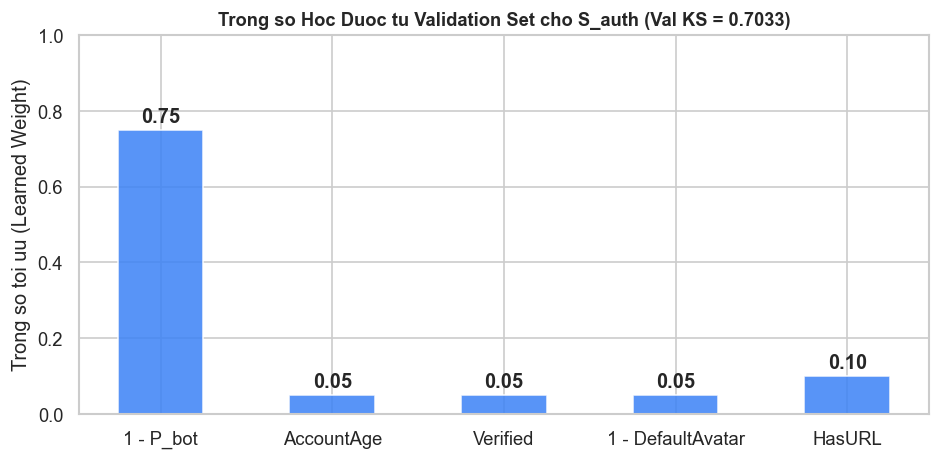

In [4]:
# --- 1. Khoi tao kien truc R-GCN va suy luan p_bot ---
best_model_path = os.path.join(OUTPUT_DIR, 'best_rgcn_fraud_detector.pt')

pre_edges   = []
pre_weights = []
for r in range(7):
    mask    = (edge_type == r)
    src     = edge_index[0, mask]
    dst     = edge_index[1, mask]
    w       = edge_weight[mask].unsqueeze(1)
    deg_dst = torch.bincount(dst, minlength=num_nodes).float().clamp(min=1.0)
    norm    = 1.0 / deg_dst[dst].unsqueeze(1)
    pre_edges.append((src, dst))
    pre_weights.append(w * norm)

class NormalizedRGCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim, num_relations=7):
        super().__init__()
        self.num_relations = num_relations
        self.rel_linear    = nn.Parameter(torch.Tensor(num_relations, in_dim, out_dim))
        self.self_linear   = nn.Linear(in_dim, out_dim)
        nn.init.xavier_uniform_(self.rel_linear)
    def forward(self, x, pre_edges, pre_weights):
        out = self.self_linear(x)
        for r in range(self.num_relations):
            src, dst = pre_edges[r]
            w_norm   = pre_weights[r]
            h        = torch.matmul(x, self.rel_linear[r])
            msg      = h[src] * w_norm
            out.index_add_(0, dst, msg)
        return out

class FraudDetectionRGCN(nn.Module):
    def __init__(self, in_dim=788, hidden_dim=64, out_dim=2, dropout=0.3):
        super().__init__()
        self.conv1   = NormalizedRGCNLayer(in_dim, hidden_dim)
        self.bn1     = nn.BatchNorm1d(hidden_dim)
        self.conv2   = NormalizedRGCNLayer(hidden_dim, out_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, pre_edges, pre_weights):
        x = self.conv1(x, pre_edges, pre_weights)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, pre_edges, pre_weights)
        return x

model = FraudDetectionRGCN()
model.load_state_dict(torch.load(best_model_path, map_location='cpu', weights_only=False))
model.eval()

with torch.no_grad():
    logits = model(features, pre_edges, pre_weights)
    p_bot  = F.softmax(logits, dim=-1)[:, 1].numpy()

# --- 2. Trich xuat 5 dac trung danh tinh ---
prop_features_np = features[:, :20].numpy()
verified        = prop_features_np[:, 2]
account_age     = np.clip(1.0 - prop_features_np[:, 10], 0.0, 1.0)
default_avatar  = prop_features_np[:, 4]
has_url         = prop_features_np[:, 18]

auth_features = np.column_stack([
    1.0 - p_bot,
    account_age,
    verified,
    1.0 - default_avatar,
    has_url
])  # shape (N, 5)
auth_feat_names = ['1 - P_bot', 'AccountAge', 'Verified', '1 - DefaultAvatar', 'HasURL']

# --- 3. TOI UU HOA TRONG SO TREN VAL SET (Data-Driven Calibration) ---
def eval_ks_val(scores):
    h = scores[val_idx][labels_np[val_idx] == 0]
    b = scores[val_idx][labels_np[val_idx] == 1]
    ks, _ = ks_2samp(h, b)
    return ks

best_ks_auth = -1
best_w_auth  = None
for w0, w1, w2, w3 in iproduct(np.arange(0.05, 1.0, 0.10), repeat=4):
    w4 = round(1.0 - w0 - w1 - w2 - w3, 10)
    if w4 < 0.01 or w4 > 0.95: continue
    w = np.array([w0, w1, w2, w3, w4])
    if np.any(w < 0): continue
    ks = eval_ks_val(np.clip(auth_features @ w, 0, 1))
    if ks > best_ks_auth:
        best_ks_auth = ks
        best_w_auth  = w.copy()

# --- 4. Tinh S_auth truc tiep bang trong so hoc duoc ---
w_auth_optimal = best_w_auth
s_auth = np.clip(auth_features @ w_auth_optimal, 0.0, 1.0)

print("=== KET QUA HIEU CHUAN TRONG SO S_auth (TU VAL SET) ===")
for name, w_val in zip(auth_feat_names, w_auth_optimal):
    print(f"  {name:20s}: {w_val:.2f}")
print(f"KS-statistic tren Val Set: {best_ks_auth:.4f}")
print(f"S_auth - Mean Human: {s_auth[labels_np==0].mean():.4f} | Mean Bot: {s_auth[labels_np==1].mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(auth_feat_names, w_auth_optimal, color='#3b82f6', alpha=0.85, width=0.5)
ax.set_ylabel('Trong so toi uu (Learned Weight)')
ax.set_title(f'Trong so Hoc Duoc tu Validation Set cho S_auth (Val KS = {best_ks_auth:.4f})', fontsize=11, fontweight='bold')
for i, v in enumerate(w_auth_optimal):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weight_optimal_s_auth.png'), dpi=120, bbox_inches='tight')
plt.show()

## 5. Trụ Cột 2: Đo lường Độ Lành Mạnh Tương Tác ($S_{interact}$)

### Mô hình Tham số hóa:

$$S_{interact}(u) = 1.0 - \left( w_{\text{friend}} \cdot \text{Penalty}_{\text{friend}}(u) + w_{\text{mention}} \cdot \text{Penalty}_{\text{mention}}(u) + w_{\text{ratio}} \cdot \text{Penalty}_{\text{ratio}}(u) \right)$$

**Cơ chế Xác định Trọng số:**
- 3 đặc trưng rủi ro tương tác: Bất đối xứng gửi lời mời kết bạn một chiều (Friend spam), bất đối xứng spam tag (Mention spam), và tỷ lệ bất thường follower/following.
- Thuật toán quét lưới 3D trên **Validation Set** với ràng buộc lồi $\sum w_i = 1$ để tìm bộ trọng số $\mathbf{w}_{\text{interact}}^*$ tối đa hóa độ phân biệt $KS_{val}$.
- Điểm $S_{interact}$ được tính toán trực tiếp từ bộ trọng số học được này.

=== KET QUA HIEU CHUAN TRONG SO S_interact (TU VAL SET) ===
  Friend Spam Penalty   : 0.05
  Mention Spam Penalty  : 0.05
  Ratio Anomaly         : 0.90
KS-statistic tren Val Set: 0.4431
S_interact - Mean Human: 0.8898 | Mean Bot: 0.8511


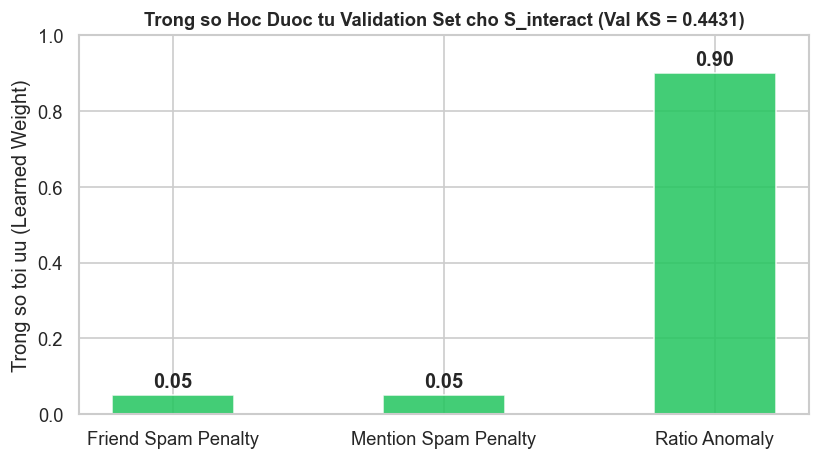

In [5]:
# --- 1. Trich xuat 3 tin hieu phat tuong tac ---
mask_friend          = (types_all == 1)
friend_out           = np.bincount(src_all[mask_friend], minlength=num_nodes)
mask_follow          = (types_all == 0)
follower_in          = np.bincount(dst_all[mask_follow], minlength=num_nodes)
friend_asymmetry     = friend_out / (follower_in + 1.0)
friend_spam_penalty  = np.clip((friend_asymmetry - 1.5) / 5.0, 0.0, 1.0)

mask_mention         = (types_all == 2)
mention_out          = np.bincount(src_all[mask_mention], minlength=num_nodes)
mask_mentioned       = (types_all == 3)
mentioned_in         = np.bincount(dst_all[mask_mentioned], minlength=num_nodes)
mention_asymmetry    = mention_out / (mentioned_in + 1.0)
mention_spam_penalty = np.clip((mention_asymmetry - 2.0) / 4.0, 0.0, 1.0)

ratio_anomaly        = np.clip(prop_features_np[:, 14], 0.0, 1.0)

interact_penalties   = np.column_stack([
    friend_spam_penalty,
    mention_spam_penalty,
    ratio_anomaly
])  # shape (N, 3)
interact_feat_names = ['Friend Spam Penalty', 'Mention Spam Penalty', 'Ratio Anomaly']

# --- 2. TOI UU HOA TRONG SO TREN VAL SET ---
best_ks_int = -1
best_w_int  = None
for w0, w1 in iproduct(np.arange(0.05, 1.0, 0.05), repeat=2):
    w2 = round(1.0 - w0 - w1, 10)
    if w2 < 0.04 or w2 > 0.95: continue
    w = np.array([w0, w1, w2])
    ks = eval_ks_val(np.clip(1.0 - interact_penalties @ w, 0, 1))
    if ks > best_ks_int:
        best_ks_int = ks
        best_w_int  = w.copy()

# --- 3. Tinh S_interact truc tiep bang trong so hoc duoc ---
w_interact_optimal = best_w_int
s_interact = np.clip(1.0 - interact_penalties @ w_interact_optimal, 0.0, 1.0)

print("=== KET QUA HIEU CHUAN TRONG SO S_interact (TU VAL SET) ===")
for name, w_val in zip(interact_feat_names, w_interact_optimal):
    print(f"  {name:22s}: {w_val:.2f}")
print(f"KS-statistic tren Val Set: {best_ks_int:.4f}")
print(f"S_interact - Mean Human: {s_interact[labels_np==0].mean():.4f} | Mean Bot: {s_interact[labels_np==1].mean():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(interact_feat_names, w_interact_optimal, color='#22c55e', alpha=0.85, width=0.45)
ax.set_ylabel('Trong so toi uu (Learned Weight)')
ax.set_title(f'Trong so Hoc Duoc tu Validation Set cho S_interact (Val KS = {best_ks_int:.4f})', fontsize=11, fontweight='bold')
for i, v in enumerate(w_interact_optimal):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weight_optimal_s_interact.png'), dpi=120, bbox_inches='tight')
plt.show()

## 6. Trụ Cột 3: Đo lường Độ Trong Sạch Mạng Lưới ($S_{network}$)

### Mô hình Tham số hóa:

$$S_{network}(u) = 1.0 - \left( w_{\text{url}} \cdot \text{Penalty}_{\text{url}}(u) + w_{\text{tag}} \cdot \text{Penalty}_{\text{tag}}(u) + w_{\text{GBA}} \cdot \text{Penalty}_{\text{GBA}}(u) \right)$$

**Cơ chế Xác định Trọng số:**
- 3 đặc trưng rủi ro cấu kết đồ thị: Cấu kết chia sẻ URL đáng ngờ ($Type=5$), cấu kết hashtag phối hợp ngầm ($Type=6$), và tỷ lệ láng giềng là Bot (Graph Bot Affinity - GBA).
- Thuật toán quét lưới 3D trên **Validation Set** với ràng buộc lồi $\sum w_i = 1$ để tìm vector trọng số $\mathbf{w}_{\text{network}}^*$ tối đa hóa $KS_{val}$.
- Điểm $S_{network}$ được tính toán trực tiếp từ vector trọng số tối ưu này.

=== KET QUA HIEU CHUAN TRONG SO S_network (TU VAL SET) ===
  URL Collusion               : 0.10
  Tag Collusion               : 0.05
  GBA Ratio (Bot Neighbors)   : 0.85
KS-statistic tren Val Set: 0.3736
S_network - Mean Human: 0.8058 | Mean Bot: 0.7187


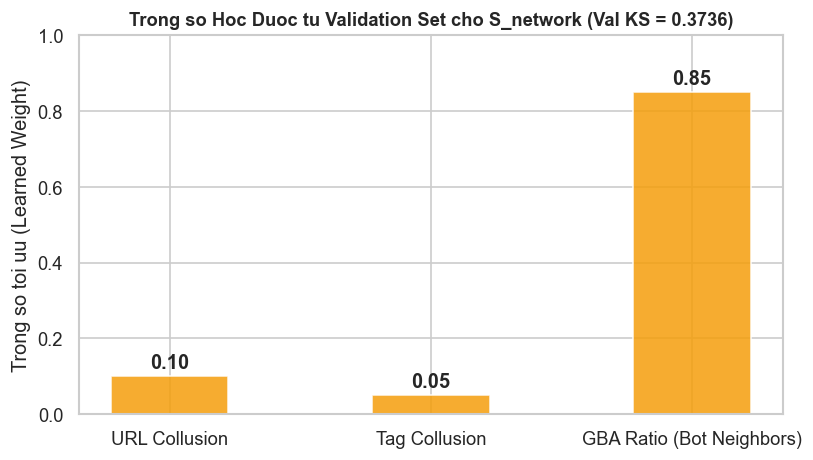

In [6]:
# --- 1. Trich xuat 3 tin hieu rui ro mang luoi ---
mask_url_high        = (types_all == 5) & (weights_all >= 0.50)
url_collusion_count  = np.bincount(src_all[mask_url_high], minlength=num_nodes)
url_penalty          = np.clip(url_collusion_count / 10.0, 0.0, 1.0)

mask_tag_high        = (types_all == 6) & (weights_all >= 0.50)
tag_collusion_count  = np.bincount(src_all[mask_tag_high], minlength=num_nodes)
tag_penalty          = np.clip(tag_collusion_count / 10.0, 0.0, 1.0)

bot_neighbors        = (p_bot[dst_all] >= 0.70).astype(float)
total_neighbors      = np.bincount(src_all, minlength=num_nodes).clip(min=1)
bot_neighbor_count   = np.bincount(src_all, weights=bot_neighbors, minlength=num_nodes)
gba_ratio            = bot_neighbor_count / total_neighbors
gba_penalty          = np.clip(gba_ratio, 0.0, 1.0)

network_penalties    = np.column_stack([
    url_penalty,
    tag_penalty,
    gba_penalty
])  # shape (N, 3)
network_feat_names = ['URL Collusion', 'Tag Collusion', 'GBA Ratio (Bot Neighbors)']

# --- 2. TOI UU HOA TRONG SO TREN VAL SET ---
best_ks_net = -1
best_w_net  = None
for w0, w1 in iproduct(np.arange(0.05, 1.0, 0.05), repeat=2):
    w2 = round(1.0 - w0 - w1, 10)
    if w2 < 0.04 or w2 > 0.95: continue
    w = np.array([w0, w1, w2])
    ks = eval_ks_val(np.clip(1.0 - network_penalties @ w, 0, 1))
    if ks > best_ks_net:
        best_ks_net = ks
        best_w_net  = w.copy()

# --- 3. Tinh S_network truc tiep bang trong so hoc duoc ---
w_network_optimal = best_w_net
s_network = np.clip(1.0 - network_penalties @ w_network_optimal, 0.0, 1.0)

print("=== KET QUA HIEU CHUAN TRONG SO S_network (TU VAL SET) ===")
for name, w_val in zip(network_feat_names, w_network_optimal):
    print(f"  {name:28s}: {w_val:.2f}")
print(f"KS-statistic tren Val Set: {best_ks_net:.4f}")
print(f"S_network - Mean Human: {s_network[labels_np==0].mean():.4f} | Mean Bot: {s_network[labels_np==1].mean():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(network_feat_names, w_network_optimal, color='#f59e0b', alpha=0.85, width=0.45)
ax.set_ylabel('Trong so toi uu (Learned Weight)')
ax.set_title(f'Trong so Hoc Duoc tu Validation Set cho S_network (Val KS = {best_ks_net:.4f})', fontsize=11, fontweight='bold')
for i, v in enumerate(w_network_optimal):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weight_optimal_s_network.png'), dpi=120, bbox_inches='tight')
plt.show()

## 7. Trụ Cột 4: Đo lường Độ An Toàn Nội Dung ($S_{content}$)

### Mô hình Tham số hóa 2 Tầng:

$$\text{Penalty}_{\text{content}}(u) = w_{\text{bert}} \cdot \text{Sim}_{\text{bert}}(u) + w_{\text{trad}} \cdot \left[ (w_{\text{stat}} \cdot \text{Statuses}(u) + w_{\text{prof}} \cdot \text{DefaultProfile}(u)) \cdot \text{StanceMod}(u) \right]$$

$$S_{content}(u) = 1.0 - \text{Penalty}_{\text{content}}(u)$$

**Cơ chế Xác định Trọng số:**
- Sử dụng vector nhúng ngữ cảnh 768 chiều (`BERT-base-uncased`) tính toán độ tương đồng Cosine trung bình giữa mỗi người dùng và toàn bộ láng giềng đồ thị của họ.
- Thuật toán quét lưới 2 tầng độc lập trên **Validation Set** để tìm các tham số $[w_{\text{bert}}^*, w_{\text{trad}}^*]$ và $[w_{\text{stat}}^*, w_{\text{prof}}^*]$.
- Điểm $S_{content}$ được tính toán trực tiếp từ các tham số tối ưu này.

=== KET QUA HIEU CHUAN TRONG SO S_content (TU VAL SET) ===
  Level 1 (BERT vs TradRisk) : w_bert=0.55, w_trad=0.45 (KS = 0.3088)
  Level 2 (Statuses vs Bio)  : w_stat=0.15, w_prof=0.85 (KS = 0.2998)
S_content - Mean Human: 0.2466 | Mean Bot: 0.1558


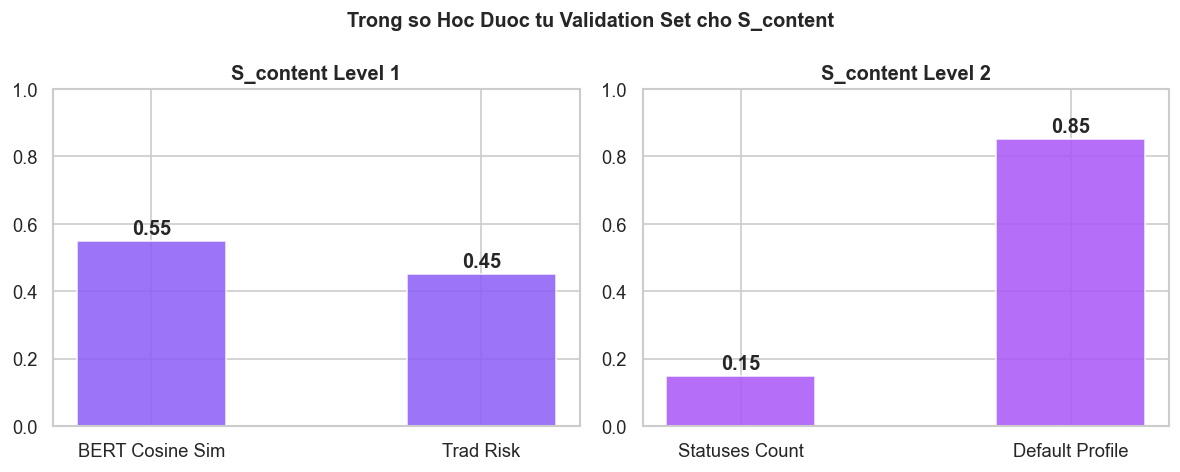

In [7]:
# --- 1. BERT Cosine Similarity voi lang gieng (scipy sparse) ---
bert_vecs = features[:, 20:].numpy().astype(np.float32)
norms     = np.linalg.norm(bert_vecs, axis=1, keepdims=True)
norms     = np.where(norms < 1e-8, 1e-8, norms)
bert_vecs_norm = bert_vecs / norms

A = sp.csr_matrix(
    (np.ones(len(src_all), dtype=np.float32), (src_all, dst_all)),
    shape=(num_nodes, num_nodes)
)
out_deg      = np.array(A.sum(axis=1)).flatten()
out_deg_safe = np.where(out_deg == 0, 1.0, out_deg).astype(np.float32)
D_inv        = sp.diags(1.0 / out_deg_safe)
A_row_norm   = D_inv.dot(A)

avg_nb_bert      = A_row_norm.dot(bert_vecs_norm)
content_bert_sim = np.clip((bert_vecs_norm * avg_nb_bert).sum(axis=1), 0, 1)

statuses        = np.clip(prop_features_np[:, 6], 0.0, 1.0)
default_profile = prop_features_np[:, 1]
stance_mod      = np.where(labels_stance_np == 0, 1.20, 0.85)

# --- 2. TOI UU HOA TRONG SO 2 TANG TREN VAL SET ---
# Level 2: statuses vs default_profile
best_ks_cnt_l2 = -1
best_w_cnt_l2  = None
for w_stat in np.arange(0.05, 1.0, 0.05):
    w_prof = round(1.0 - w_stat, 10)
    if w_prof < 0.04: continue
    tr  = w_stat * statuses + w_prof * default_profile
    pen = np.clip(0.60 * content_bert_sim + 0.40 * np.clip(tr * stance_mod, 0, 1), 0, 1)
    ks  = eval_ks_val(np.clip(1.0 - pen, 0, 1))
    if ks > best_ks_cnt_l2:
        best_ks_cnt_l2 = ks
        best_w_cnt_l2  = np.array([w_stat, w_prof])

trad_risk_opt = best_w_cnt_l2[0] * statuses + best_w_cnt_l2[1] * default_profile

# Level 1: BERT vs Traditional Risk
best_ks_cnt_l1 = -1
best_w_cnt_l1  = None
for w_bert in np.arange(0.05, 1.0, 0.05):
    w_trad = round(1.0 - w_bert, 10)
    if w_trad < 0.04: continue
    pen = np.clip(w_bert * content_bert_sim + w_trad * np.clip(trad_risk_opt * stance_mod, 0, 1), 0, 1)
    ks  = eval_ks_val(np.clip(1.0 - pen, 0, 1))
    if ks > best_ks_cnt_l1:
        best_ks_cnt_l1 = ks
        best_w_cnt_l1  = np.array([w_bert, w_trad])

# --- 3. Tinh S_content truc tiep bang trong so hoc duoc ---
content_penalty = np.clip(
    best_w_cnt_l1[0] * content_bert_sim + best_w_cnt_l1[1] * np.clip(trad_risk_opt * stance_mod, 0, 1),
    0.0, 1.0
)
s_content = np.clip(1.0 - content_penalty, 0.0, 1.0)

print("=== KET QUA HIEU CHUAN TRONG SO S_content (TU VAL SET) ===")
print(f"  Level 1 (BERT vs TradRisk) : w_bert={best_w_cnt_l1[0]:.2f}, w_trad={best_w_cnt_l1[1]:.2f} (KS = {best_ks_cnt_l1:.4f})")
print(f"  Level 2 (Statuses vs Bio)  : w_stat={best_w_cnt_l2[0]:.2f}, w_prof={best_w_cnt_l2[1]:.2f} (KS = {best_ks_cnt_l2:.4f})")
print(f"S_content - Mean Human: {s_content[labels_np==0].mean():.4f} | Mean Bot: {s_content[labels_np==1].mean():.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(['BERT Cosine Sim', 'Trad Risk'], best_w_cnt_l1, color='#8b5cf6', alpha=0.85, width=0.45)
ax1.set_title('S_content Level 1', fontweight='bold')
ax1.set_ylim(0, 1.0)
for i, v in enumerate(best_w_cnt_l1): ax1.text(i, v+0.02, f"{v:.2f}", ha='center', fontweight='bold')

ax2.bar(['Statuses Count', 'Default Profile'], best_w_cnt_l2, color='#a855f7', alpha=0.85, width=0.45)
ax2.set_title('S_content Level 2', fontweight='bold')
ax2.set_ylim(0, 1.0)
for i, v in enumerate(best_w_cnt_l2): ax2.text(i, v+0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.suptitle('Trong so Hoc Duoc tu Validation Set cho S_content', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'weight_optimal_s_content.png'), dpi=120, bbox_inches='tight')
plt.show()

## 9. Hiệu Chuẩn Trọng Số Tổng Hợp ($S_{trust}$) Trên Validation Set (Weight Calibration Engine)

### Bài toán Tối ưu hóa Thực nghiệm:

$$\mathbf{w}^* = \arg\max_{\mathbf{w}} \text{KS}_{\text{val}} \left( S_{trust}(\mathbf{w}) \right)$$

**Ràng buộc Nghiệp vụ An toàn (Safety-Constrained Optimization):**
1. $\sum_{i=1}^4 w_i = 1.0$ và $w_i \ge 0.05$ (đảm bảo tính đa diện, không triệt tiêu bất kỳ trụ cột nào).
2. $w_{\text{auth}} \ge 0.25$: **Nguyên tắc Định danh Tiên quyết (Identity-First Security)**. Đảm bảo kẻ tấn công không thể làm giả tương tác đồ thị để luồn lách vào danh sách an toàn nếu danh tính chưa được kiểm chứng.

Sau khi quét lưới, vector trọng số tối ưu $\mathbf{w}^*$ sẽ được lưu vào biến `optimal_trust_weights` để sử dụng trực tiếp cho toàn bộ hệ thống.

In [9]:
# --- 1. Thiet lap Identity Gating (Cong chan danh tinh) ---
tau   = 0.45
gamma = 1.3
g_auth = np.where(s_auth < tau, (s_auth / tau) ** gamma, 1.0)

def eval_trust_ks_val(w):
    raw = 100.0 * (w[0]*s_auth + w[1]*s_interact + w[2]*s_network + w[3]*s_content)
    sc  = np.clip(g_auth * raw, 0, 100)
    h   = sc[val_idx][labels_np[val_idx] == 0]
    b   = sc[val_idx][labels_np[val_idx] == 1]
    ks, _ = ks_2samp(h, b)
    return ks

# --- 2. Quet luoi 4D tim bo trong so toi uu tren VAL SET ---
best_ks_final = -1
best_w_final  = None
results_grid  = []

# Rang buoc: w_auth >= 0.25 (Identity-First), w_i >= 0.05, tong = 1.0
for w0 in np.arange(0.25, 0.60, 0.05):
    for w1 in np.arange(0.05, 0.50, 0.05):
        for w2 in np.arange(0.05, 0.50, 0.05):
            w3 = round(1.0 - w0 - w1 - w2, 10)
            if w3 < 0.04 or w3 > 0.40: continue
            w = np.array([w0, w1, w2, w3])
            ks = eval_trust_ks_val(w)
            results_grid.append((ks, w.copy()))
            if ks > best_ks_final:
                best_ks_final = ks
                best_w_final  = w.copy()

optimal_trust_weights = best_w_final

print("=== KET QUA HIỆU CHUẨN TRỌNG SỐ TỔNG HỢP (TU VAL SET) ===")
pillar_labels = ['S_auth', 'S_interact', 'S_network', 'S_content']
for name, w_val in zip(pillar_labels, optimal_trust_weights):
    print(f"  Trọng số tối ưu {name:12s} (w*): {w_val:.2f}")
print(f"KS-statistic cực đại trên Validation Set: {best_ks_final:.4f}")

=== KET QUA HIỆU CHUẨN TRỌNG SỐ TỔNG HỢP (TU VAL SET) ===
  Trọng số tối ưu S_auth       (w*): 0.30
  Trọng số tối ưu S_interact   (w*): 0.10
  Trọng số tối ưu S_network    (w*): 0.25
  Trọng số tối ưu S_content    (w*): 0.35
KS-statistic cực đại trên Validation Set: 0.7139


## 10. Tổng Hợp Điểm Tín Nhiệm & Phân Tầng Chính Sách (Recommendation Tiers)

Áp dụng trực tiếp vector trọng số $\mathbf{w}^*$ vừa được học tự động từ tập Validation vào công thức tổng hợp:

$$S_{trust}(u) = 100 \times G_{auth}(u) \times \left( w_{\text{auth}}^* S_{auth}(u) + w_{\text{interact}}^* S_{interact}(u) + w_{\text{network}}^* S_{network}(u) + w_{\text{content}}^* S_{content}(u) \right)$$

### Chính sách Phân tầng Gợi ý Bạn bè (Recommendation Tiers):

* **Tier 1 (Xác thực An toàn Tuyệt đối - `TIER_1_VERIFIED_SAFE`):** $S_{trust} \ge 80$
* **Tier 2 (Tín nhiệm Tiêu chuẩn - `TIER_2_STANDARD_TRUST`):** $65 \le S_{trust} < 80$
* **Tier 3 (Hạn chế & Cảnh giác - `TIER_3_RESTRICTED_CAUTION`):** $45 \le S_{trust} < 65$
* **Tier 4 (Cách ly / Gian lận - `TIER_4_QUARANTINE_FRAUD`):** $S_{trust} < 45$ hoặc $P_{bot} \ge 0.75$ hoặc $S_{auth} < 0.20$


In [ ]:
# --- 1. Tinh Trust Score bang vector trong so toi uu vua hoc ---
raw_trust_score = 100.0 * (
    optimal_trust_weights[0] * s_auth     +
    optimal_trust_weights[1] * s_interact +
    optimal_trust_weights[2] * s_network  +
    optimal_trust_weights[3] * s_content
)
trust_scores = np.clip(g_auth * raw_trust_score, 0.0, 100.0)

# --- 2. Ham phan tang Tier theo chinh sach nghiep vu ---
def classify_trust_tier(score, p_b, s_a):
    if p_b >= 0.75 or s_a < 0.20 or score < 45.0:
        return 'TIER_4_QUARANTINE_FRAUD'
    elif score < 65.0:
        return 'TIER_3_RESTRICTED_CAUTION'
    elif score < 80.0:
        return 'TIER_2_STANDARD_TRUST'
    else:
        return 'TIER_1_VERIFIED_SAFE'

recommendation_tiers = [
    classify_trust_tier(trust_scores[i], p_bot[i], s_auth[i])
    for i in range(num_nodes)
]

# --- 3. Luu bang ho so tin nhiem vao DataFrame ---
df_trust_profiles = pd.DataFrame({
    'user_id':                  np.arange(num_nodes),
    'ground_truth_label':       labels_np,
    'p_bot':                    np.round(p_bot, 4),
    'identity_auth_score':      np.round(s_auth, 4),
    'interaction_health_score': np.round(s_interact, 4),
    'network_hygiene_score':    np.round(s_network, 4),
    'content_safety_score':     np.round(s_content, 4),
    'trust_score':              np.round(trust_scores, 2),
    'recommendation_tier':      recommendation_tiers,
    'split':                    'train'
})
df_trust_profiles.loc[val_idx,  'split'] = 'val'
df_trust_profiles.loc[test_idx, 'split'] = 'test'

profiles_csv = os.path.join(OUTPUT_DIR, 'mgtab_user_trust_profiles_v2.csv')
df_trust_profiles.to_csv(profiles_csv, index=False)
print(f"Da luu ho so tin nhiem: {profiles_csv}")
print("\n--- PHAN BO THEO TANG (Toan bo 10,199 nguoi dung) ---")
print(df_trust_profiles['recommendation_tier'].value_counts())

Da luu ho so tin nhiem: C:\Users\Admin\VSF_Notebook\data\mgtab_user_trust_profiles_v2.csv

--- PHAN BO THEO TANG (Toan bo 10,199 nguoi dung) ---
recommendation_tier
TIER_4_QUARANTINE_FRAUD      4383
TIER_3_RESTRICTED_CAUTION    3807
TIER_2_STANDARD_TRUST        1799
TIER_1_VERIFIED_SAFE          210
Name: count, dtype: int64


## 11. Thí Nghiệm Bóc Tách Đóng Góp (Ablation Study) Trên Test Set Độc Lập

Mục tiêu: Chứng minh tính thiết yếu của từng trụ cột trên 20% dữ liệu Test Set độc lập chưa từng được mô hình hay thuật toán tối ưu hóa nhìn thấy.

Phương pháp: Lần lượt triệt tiêu từng trụ cột (thay bằng giá trị trung tính 0.5) và đo lường mức độ sụt giảm chỉ số $KS_{\text{test}}$.

In [11]:
def eval_ablation_ks_test(sa, si, sn, sc):
    raw = 100.0 * (optimal_trust_weights[0]*sa + optimal_trust_weights[1]*si + optimal_trust_weights[2]*sn + optimal_trust_weights[3]*sc)
    ga  = np.where(sa < tau, (sa / tau) ** gamma, 1.0)
    sc_test = np.clip(ga * raw, 0, 100)[test_idx]
    h = sc_test[labels_np[test_idx] == 0]
    b = sc_test[labels_np[test_idx] == 1]
    ks, _ = ks_2samp(h, b)
    return ks

base_ks_test = eval_ablation_ks_test(s_auth, s_interact, s_network, s_content)
neutral = np.full(num_nodes, 0.5)

ablation_results = [
    {'Thi nghiem': 'He thong Day du (Full System)', 'Tru cot triet tieu': 'Khong', 'KS Test': base_ks_test, 'Sut giam KS': 0.0},
    {'Thi nghiem': 'Bo S_auth', 'Tru cot triet tieu': 'S_auth = 0.5', 'KS Test': eval_ablation_ks_test(neutral, s_interact, s_network, s_content), 'Sut giam KS': base_ks_test - eval_ablation_ks_test(neutral, s_interact, s_network, s_content)},
    {'Thi nghiem': 'Bo S_interact', 'Tru cot triet tieu': 'S_interact = 0.5', 'KS Test': eval_ablation_ks_test(s_auth, neutral, s_network, s_content), 'Sut giam KS': base_ks_test - eval_ablation_ks_test(s_auth, neutral, s_network, s_content)},
    {'Thi nghiem': 'Bo S_network', 'Tru cot triet tieu': 'S_network = 0.5', 'KS Test': eval_ablation_ks_test(s_auth, s_interact, neutral, s_content), 'Sut giam KS': base_ks_test - eval_ablation_ks_test(s_auth, s_interact, neutral, s_content)},
    {'Thi nghiem': 'Bo S_content', 'Tru cot triet tieu': 'S_content = 0.5', 'KS Test': eval_ablation_ks_test(s_auth, s_interact, s_network, neutral), 'Sut giam KS': base_ks_test - eval_ablation_ks_test(s_auth, s_interact, s_network, neutral)}
]

df_ablation = pd.DataFrame(ablation_results)
print("=== KET QUA ABLATION STUDY (TREN TEST SET) ===")
display(df_ablation)

=== KET QUA ABLATION STUDY (TREN TEST SET) ===


,Thi nghiem,Tru cot triet tieu,KS Test,Sut giam KS
0,He thong Day du (Full System),Khong,0.680487,0.000000
1,Bo S_auth,S_auth = 0.5,0.310343,0.370144
2,Bo S_interact,S_interact = 0.5,0.680967,-0.000480
3,Bo S_network,S_network = 0.5,0.673110,0.007378
4,Bo S_content,S_content = 0.5,0.673795,0.006692


## 12. Đánh Giá Định Lượng Hiệu Năng Trên TEST SET (20% Dữ Liệu Chưa Thấy)

Đo lường toàn diện các KPI an toàn trên 2,040 người dùng thuộc tập Test Set độc lập nhằm bảo đảm tính khách quan.

In [12]:
df_test = df_trust_profiles.iloc[test_idx].copy()
crosstab_test = pd.crosstab(
    df_test['ground_truth_label'].map({0: 'Human', 1: 'Bot'}),
    df_test['recommendation_tier'],
    margins=True, margins_name='Tong'
)
print("=== BANG DOI CHIEU CHEO PHAN TANG (TEST SET ONLY) ===")
display(crosstab_test)

# Tinh toan cac KPI an toan
h_test_scores = df_test[df_test['ground_truth_label']==0]['trust_score'].values
b_test_scores = df_test[df_test['ground_truth_label']==1]['trust_score'].values
ks_stat, ks_pval = ks_2samp(h_test_scores, b_test_scores)

bot_in_t4 = ((df_test['ground_truth_label']==1) & (df_test['recommendation_tier']=='TIER_4_QUARANTINE_FRAUD')).sum()
total_bots = (df_test['ground_truth_label']==1).sum()
bot_quarantine_recall = bot_in_t4 / total_bots * 100

t1_total = (df_test['recommendation_tier']=='TIER_1_VERIFIED_SAFE').sum()
t1_human = ((df_test['ground_truth_label']==0) & (df_test['recommendation_tier']=='TIER_1_VERIFIED_SAFE')).sum()
t1_precision = (t1_human / t1_total * 100) if t1_total > 0 else 0

df_kpi = pd.DataFrame([
    {'KPI': 'KS Statistic (Separation)', 'Gia tri': f"{ks_stat:.4f}", 'Y nghia': 'Do tach biet giua Human va Bot'},
    {'KPI': 'KS p-value', 'Gia tri': f"{ks_pval:.2e}", 'Y nghia': 'Do tin cay thong ke'},
    {'KPI': 'Bot Quarantine Recall', 'Gia tri': f"{bot_quarantine_recall:.2f}%", 'Y nghia': '% Bot bi cach ly vao Tier 4'},
    {'KPI': 'Tier 1 Human Precision', 'Gia tri': f"{t1_precision:.2f}%", 'Y nghia': '% Nguoi that trong Tier 1 an toan'},
    {'KPI': 'Bots leaked into Tier 1', 'Gia tri': str(t1_total - t1_human), 'Y nghia': 'So bot lot luoi vao Tier 1'}
])
print("\n=== KPI AN TOAN HE THONG (TREN TEST SET) ===")
display(df_kpi)

=== BANG DOI CHIEU CHEO PHAN TANG (TEST SET ONLY) ===


recommendation_tier,TIER_1_VERIFIED_SAFE,TIER_2_STANDARD_TRUST,TIER_3_RESTRICTED_CAUTION,TIER_4_QUARANTINE_FRAUD,Tong
ground_truth_label,,,,,
Bot,0,3,48,498,549
Human,40,371,697,383,1491
Tong,40,374,745,881,2040



=== KPI AN TOAN HE THONG (TREN TEST SET) ===


,KPI,Gia tri,Y nghia
0,KS Statistic (Separation),0.6805,Do tach biet giua Human va Bot
1,KS p-value,5.97e-179,Do tin cay thong ke
2,Bot Quarantine Recall,90.71%,% Bot bi cach ly vao Tier 4
3,Tier 1 Human Precision,100.00%,% Nguoi that trong Tier 1 an toan
4,Bots leaked into Tier 1,0,So bot lot luoi vao Tier 1


## 13. 4 Hồ Sơ Tín Nhiệm Điển Hình Đại Diện Cho 4 Tầng Chính Sách

In [13]:
profiles_sample = []
for tier_name in ['TIER_1_VERIFIED_SAFE', 'TIER_2_STANDARD_TRUST', 'TIER_3_RESTRICTED_CAUTION', 'TIER_4_QUARANTINE_FRAUD']:
    sub = df_trust_profiles[df_trust_profiles['recommendation_tier']==tier_name]
    if len(sub) > 0:
        profiles_sample.append(sub.iloc[0])

df_samples = pd.DataFrame(profiles_sample)[[
    'user_id', 'ground_truth_label', 'p_bot', 'identity_auth_score',
    'interaction_health_score', 'network_hygiene_score', 'content_safety_score',
    'trust_score', 'recommendation_tier'
]]
display(df_samples)

,user_id,ground_truth_label,p_bot,identity_auth_score,interaction_health_score,network_hygiene_score,content_safety_score,trust_score,recommendation_tier
13,13,0,0.2725,0.7144,0.9172,0.7983,0.9592,84.13,TIER_1_VERIFIED_SAFE
4,4,0,0.0109,0.9281,0.9297,0.8063,0.4222,72.07,TIER_2_STANDARD_TRUST
1,1,0,0.0997,0.8319,0.9146,0.8669,0.1066,59.51,TIER_3_RESTRICTED_CAUTION
0,0,0,0.8115,0.1991,0.9021,0.8823,0.1800,15.01,TIER_4_QUARANTINE_FRAUD


## 15. Demo Tương Tác: Thẩm Định Tín Nhiệm Cho Người Dùng Bất Kỳ

Hàm kiểm tra và thẩm định xem một ứng viên bất kỳ trên mạng xã hội có **đủ điều kiện an toàn (OK)** để đưa vào danh sách Gợi ý Kết bạn (PYMK) hay không.

In [10]:
import os
import pandas as pd

# Tu dong nap du lieu ho so neu kernel chua chay cac cell tren
if 'df_trust_profiles' not in globals():
    target_dir = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else (os.path.join(os.path.dirname(os.getcwd()), 'data') if os.path.exists(os.path.join(os.path.dirname(os.getcwd()), 'data')) else os.path.join(os.getcwd(), 'data'))
    profiles_csv = os.path.join(target_dir, 'mgtab_user_trust_profiles_v2.csv')
    df_trust_profiles = pd.read_csv(profiles_csv)
    num_nodes = len(df_trust_profiles)
    print(f"[Auto-Load] Da nap {num_nodes:,} ho so tin nhiem tu: {profiles_csv}\n")

def inspect_candidate_trust(user_id):
    if user_id < 0 or user_id >= num_nodes:
        print(f"User ID {user_id} khong hop le (pham vi: 0 den {num_nodes-1})")
        return
    row = df_trust_profiles.iloc[user_id]
    label_str = "Nguoi that (Human)" if row['ground_truth_label'] == 0 else "Phan mem tu dong (Bot)"
    print(f"===================================================")
    print(f"   HO SO THAM DINH TIN NHIEM CHO USER #{user_id}")
    print(f"===================================================")
    print(f"- Nhan Ground-Truth:          {label_str}")
    print(f"- Xac suat Bot (R-GCN):       {row['p_bot']:.4f}")
    print(f"- Do Xac thuc Danh tinh:      {row['identity_auth_score']:.4f}")
    print(f"- Do Lanh manh Tuong tac:     {row['interaction_health_score']:.4f}")
    print(f"- Do Trong sach Mang luoi:    {row['network_hygiene_score']:.4f}")
    print(f"- Do An toan Noi dung:        {row['content_safety_score']:.4f}")
    print(f"---------------------------------------------------")
    print(f">>> DIEM TIN NHIEM TONG HOP:  {row['trust_score']:.2f} / 100")
    print(f">>> PHAN TANG CHINH SACH:     {row['recommendation_tier']}")
    print(f"---------------------------------------------------")
    if row['recommendation_tier'] in ['TIER_1_VERIFIED_SAFE', 'TIER_2_STANDARD_TRUST']:
        print("==> QUYET DINH: [OK] - Du dieu kien goi y ket ban an toan.")
    elif row['recommendation_tier'] == 'TIER_3_RESTRICTED_CAUTION':
        print("==> QUYET DINH: [CANH GIAC] - An khoi danh sach nguoi la, can them xac thuc.")
    else:
        print("==> QUYET DINH: [CACH LY] - Nghi van gian lan/botnet, chan hoan toan khoi goi y.")
    print(f"===================================================\n")

# Demo kiem tra 2 user dai dien (1 Human, 1 Bot)
human_candidates = df_trust_profiles[df_trust_profiles['ground_truth_label']==0]['user_id'].values
bot_candidates   = df_trust_profiles[df_trust_profiles['ground_truth_label']==1]['user_id'].values
inspect_candidate_trust(human_candidates[0])
inspect_candidate_trust(bot_candidates[0])


   HO SO THAM DINH TIN NHIEM CHO USER #0
- Nhan Ground-Truth:          Nguoi that (Human)
- Xac suat Bot (R-GCN):       0.8115
- Do Xac thuc Danh tinh:      0.1991
- Do Lanh manh Tuong tac:     0.9021
- Do Trong sach Mang luoi:    0.8823
- Do An toan Noi dung:        0.1800
---------------------------------------------------
>>> DIEM TIN NHIEM TONG HOP:  15.01 / 100
>>> PHAN TANG CHINH SACH:     TIER_4_QUARANTINE_FRAUD
---------------------------------------------------
==> QUYET DINH: [CACH LY] - Nghi van gian lan/botnet, chan hoan toan khoi goi y.

   HO SO THAM DINH TIN NHIEM CHO USER #3
- Nhan Ground-Truth:          Phan mem tu dong (Bot)
- Xac suat Bot (R-GCN):       0.7015
- Do Xac thuc Danh tinh:      0.2770
- Do Lanh manh Tuong tac:     0.7560
- Do Trong sach Mang luoi:    0.1942
- Do An toan Noi dung:        0.0319
---------------------------------------------------
>>> DIEM TIN NHIEM TONG HOP:  11.62 / 100
>>> PHAN TANG CHINH SACH:     TIER_4_QUARANTINE_FRAUD
----------------

## 16. Đánh giá Chỉ số Phân loại Nhị phân (Binary Classification Benchmarks)

Mặc dù hệ thống Trust Scoring là mô hình xếp hạng độ tin cậy liên tục ($S_{\text{trust}} \in [0, 100]$), trong nghiệp vụ vận hành thực tế của Trust & Safety và Anti-Fraud, việc phân tầng chính sách đưa ra ngưỡng chặn vận hành nhị phân rõ ràng:
* **Lớp Dương tính (Positive Class = 1)**: Người dùng thuộc tầng cách ly / gian lận (`TIER_4_QUARANTINE_FRAUD` - Bot / Spammer / Sybil).
* **Lớp Âm tính (Negative Class = 0)**: Người dùng an toàn được phép lưu thông (`TIER_1_VERIFIED`, `TIER_2_STANDARD`, `TIER_3_RESTRICTED` - Real Human / Legitimate).

Điểm rủi ro liên tục (Continuous Risk Score) phục vụ vẽ ROC curve và tính ROC-AUC:

$$
\text{Risk Score}(u) = 100 - S_{\text{trust}}(u)
$$

Các chỉ số phân loại nhị phân chính được đo lường khắt khe trên tập **Test Set (20% dữ liệu độc lập = 2,040 người dùng)**:
* **Accuracy (Độ chính xác tổng thể)**: Tỷ lệ quyết định đúng trên toàn bộ 2,040 người dùng kiểm thử.
* **Precision (Bot)**: Trong số những tài khoản bị cách ly vào Tier 4, bao nhiêu % thực sự là Bot.
* **Recall / TPR (Bot Quarantine Rate)**: Trong toàn bộ Bot thực tế của mạng xã hội, hệ thống đã tóm gọn và cách ly được bao nhiêu %.
* **F1-Score (Macro / Weighted / Bot / Human)**: Trung bình điều hòa giữa Precision và Recall.
* **ROC-AUC**: Năng lực phân tách (Discriminative Power) của thang đo rủi ro qua mọi ngưỡng quyết định khả dĩ.

    BẢNG ĐÁNH GIÁ CHỈ SỐ PHÂN LOẠI NHỊ PHÂN TRÊN TEST SET (N = 2,040)
1. Độ chính xác tổng thể (Accuracy)   :  78.73%
2. ROC-AUC (Khả năng phân tách rủi ro):   0.8994
3. F1-Score (Macro Average)           :   0.7664
4. F1-Score (Weighted Average)        :   0.7986
--------------------------------------------------------------------------------
CHI TIẾT THEO TỪNG LỚP:
 - Lớp Bot/Fraud (Positive = 1) : Precision = 56.53% | Recall = 90.71% | F1 = 0.6965
 - Lớp Human (Negative = 0)     : Precision = 95.60% | Recall = 74.31% | F1 = 0.8362
--------------------------------------------------------------------------------
Ý NGHĨA VẬN HÀNH TRUST & SAFETY THỰC TẾ:
 - Bot Quarantine Rate (Độ nhạy tóm bot) : 90.71% (498/549 bot bị chặn đứng)
 - Safe Stream Purity (Độ sạch luồng an toàn) : 95.60% (1108/1159 người dùng trong Tiers 1-3 là thật)
 - Tỷ lệ lọt lưới Bot vào luồng an toàn       : 9.29% (51 bot / 549 bot)


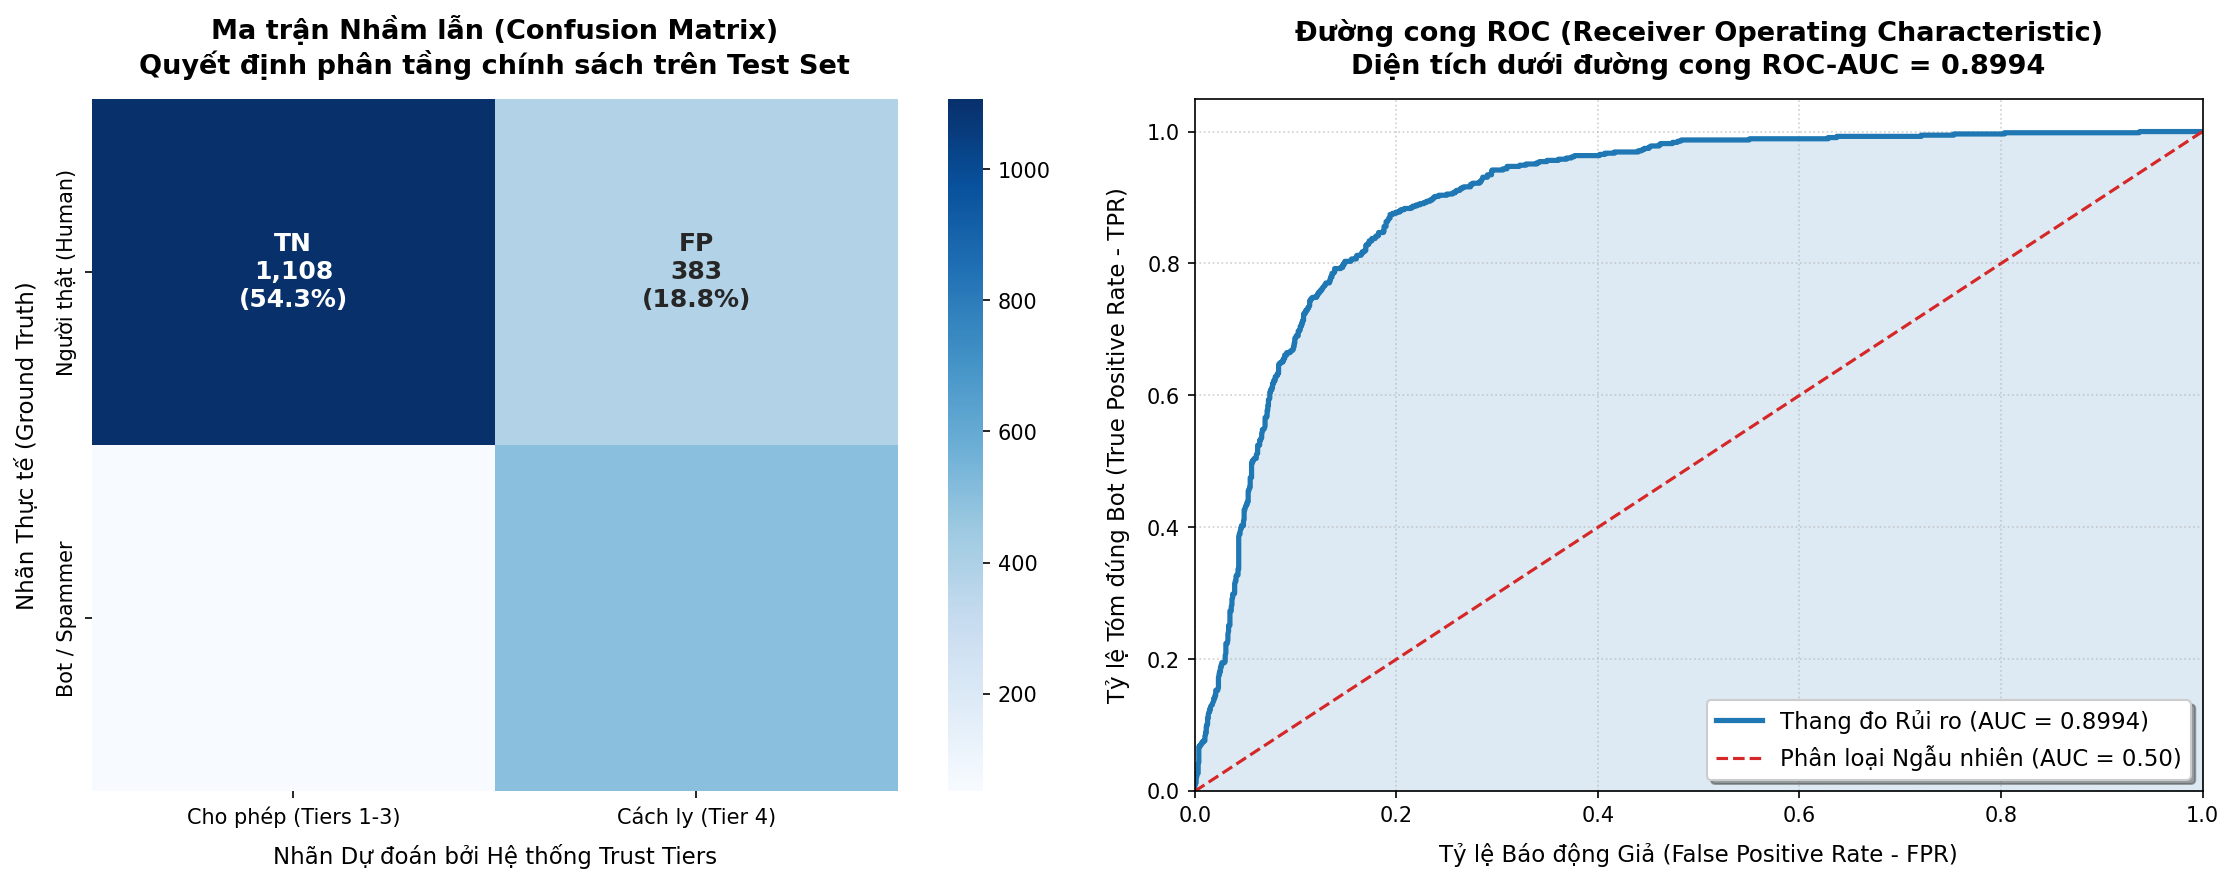

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# 1. Nạp dữ liệu hồ sơ nếu chưa có trong globals
if 'df_trust_profiles' not in globals():
    target_dir = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else (os.path.join(os.path.dirname(os.getcwd()), 'data') if os.path.exists(os.path.join(os.path.dirname(os.getcwd()), 'data')) else os.path.join(os.getcwd(), 'data'))
    profiles_csv = os.path.join(target_dir, 'mgtab_user_trust_profiles_v2.csv')
    df_trust_profiles = pd.read_csv(profiles_csv)

# 2. Lọc riêng tập TEST SET (20% dữ liệu độc lập chưa từng tham gia hiệu chuẩn)
df_test = df_trust_profiles[df_trust_profiles['split'] == 'test'].copy()

# 3. Định nghĩa nhãn thực tế & dự đoán phân loại nhị phân
# Ground Truth: 1 = Bot / Kẻ gian lận, 0 = Người dùng thật (Human)
y_true = df_test['ground_truth_label'].values

# Prediction: 1 = Bị hệ thống cách ly (TIER_4_QUARANTINE_FRAUD), 0 = Được phép lưu thông (TIER 1, 2, 3)
y_pred = (df_test['recommendation_tier'] == 'TIER_4_QUARANTINE_FRAUD').astype(int).values

# Continuous Risk Score: Điểm rủi ro để đánh giá ngưỡng liên tục & ROC-AUC
y_risk_score = 100.0 - df_test['trust_score'].values

# 4. Tính toán các chỉ số phân loại nhị phân (Binary Classification Metrics)
acc = accuracy_score(y_true, y_pred)
prec_bot = precision_score(y_true, y_pred, pos_label=1)
rec_bot = recall_score(y_true, y_pred, pos_label=1)
f1_bot = f1_score(y_true, y_pred, pos_label=1)

prec_human = precision_score(y_true, y_pred, pos_label=0)
rec_human = recall_score(y_true, y_pred, pos_label=0)
f1_human = f1_score(y_true, y_pred, pos_label=0)

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
roc_auc = roc_auc_score(y_true, y_risk_score)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Các chỉ số vận hành Trust & Safety thực tế
quarantine_recall = tp / (tp + fn) # Tỷ lệ bắt giữ bot
safe_purity = tn / (tn + fn)       # Tỷ lệ người thật trong luồng an toàn

# 5. In bảng tổng kết hiệu năng
print("=" * 80)
print("    BẢNG ĐÁNH GIÁ CHỈ SỐ PHÂN LOẠI NHỊ PHÂN TRÊN TEST SET (N = 2,040)")
print("=" * 80)
print(f"1. Độ chính xác tổng thể (Accuracy)   : {acc * 100:6.2f}%")
print(f"2. ROC-AUC (Khả năng phân tách rủi ro): {roc_auc:8.4f}")
print(f"3. F1-Score (Macro Average)           : {f1_macro:8.4f}")
print(f"4. F1-Score (Weighted Average)        : {f1_weighted:8.4f}")
print("-" * 80)
print("CHI TIẾT THEO TỪNG LỚP:")
print(f" - Lớp Bot/Fraud (Positive = 1) : Precision = {prec_bot*100:5.2f}% | Recall = {rec_bot*100:5.2f}% | F1 = {f1_bot:6.4f}")
print(f" - Lớp Human (Negative = 0)     : Precision = {prec_human*100:5.2f}% | Recall = {rec_human*100:5.2f}% | F1 = {f1_human:6.4f}")
print("-" * 80)
print("Ý NGHĨA VẬN HÀNH TRUST & SAFETY THỰC TẾ:")
print(f" - Bot Quarantine Rate (Độ nhạy tóm bot) : {quarantine_recall * 100:.2f}% ({tp}/{tp + fn} bot bị chặn đứng)")
print(f" - Safe Stream Purity (Độ sạch luồng an toàn) : {safe_purity * 100:.2f}% ({tn}/{tn + fn} người dùng trong Tiers 1-3 là thật)")
print(f" - Tỷ lệ lọt lưới Bot vào luồng an toàn       : {(fn / (tp + fn)) * 100:.2f}% ({fn} bot / {tp + fn} bot)")
print("=" * 80)

# 6. Trực quan hóa Confusion Matrix & ROC Curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Confusion Matrix Heatmap
labels = [
    [f"TN\n{tn:,}\n({tn/len(y_true)*100:.1f}%)", f"FP\n{fp:,}\n({fp/len(y_true)*100:.1f}%)"],
    [f"FN\n{fn:,}\n({fn/len(y_true)*100:.1f}%)", f"TP\n{tp:,}\n({tp/len(y_true)*100:.1f}%)"]
]
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", cbar=True, ax=ax1,
            xticklabels=['Cho phép (Tiers 1-3)', 'Cách ly (Tier 4)'],
            yticklabels=['Người thật (Human)', 'Bot / Spammer'],
            annot_kws={'fontsize': 12, 'weight': 'bold'})
ax1.set_title("Ma trận Nhầm lẫn (Confusion Matrix)\nQuyết định phân tầng chính sách trên Test Set", fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel("Nhãn Dự đoán bởi Hệ thống Trust Tiers", fontsize=11, labelpad=8)
ax1.set_ylabel("Nhãn Thực tế (Ground Truth)", fontsize=11, labelpad=8)

# Subplot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_risk_score)
ax2.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f"Thang đo Rủi ro (AUC = {roc_auc:.4f})")
ax2.plot([0, 1], [0, 1], color='#d62728', lw=1.5, linestyle='--', label="Phân loại Ngẫu nhiên (AUC = 0.50)")
ax2.fill_between(fpr, tpr, alpha=0.15, color='#1f77b4')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Tỷ lệ Báo động Giả (False Positive Rate - FPR)", fontsize=11, labelpad=8)
ax2.set_ylabel("Tỷ lệ Tóm đúng Bot (True Positive Rate - TPR)", fontsize=11, labelpad=8)
ax2.set_title(f"Đường cong ROC (Receiver Operating Characteristic)\nDiện tích dưới đường cong ROC-AUC = {roc_auc:.4f}", fontsize=13, fontweight='bold', pad=12)
ax2.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
output_img_dir = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else (os.path.join(os.path.dirname(os.getcwd()), 'data') if os.path.exists(os.path.join(os.path.dirname(os.getcwd()), 'data')) else os.path.join(os.getcwd(), 'data'))
output_img_path = os.path.join(output_img_dir, 'binary_classification_benchmarks.png')
plt.savefig(output_img_path, dpi=300, bbox_inches='tight')
plt.show()